*ТЕМА*
Сравнительный анализ классических и нейронных рекомендательных систем в сфере электронной коммерции

*ПЛАН*

1. Предобработка данных (создание датасета в разрезе клиентов)
2. Классическая кластеризация на основе табличных признаков - сегментация по клиентам 
3. Рекомендационные системы "классические"
4. Нейронные рекомендательные системы
5. Сравнение рекомендательных систем


In [1]:
import sys
print(sys.executable) 
print(sys.prefix) 


/Users/ekaterinazinoveva/Mag/bin/python
/Users/ekaterinazinoveva/Mag


In [150]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import hdbscan
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import openpyxl
from sklearn.model_selection import train_test_split

In [2]:
#! /Users/ekaterinazinoveva/Mag/bin/python -m pip install openpyxl

In [3]:
def describe_columns(df):
    data = []
    for column in df.columns:
        data.append([
            column,
            df[column].nunique(),
            (df[column] == 0).sum(),
            df[column].isna().sum(),
            round(df[column].isna().sum() / len(df) * 100, 1),
            df[column].dtypes
        ])
    
    result_df = pd.DataFrame(data, columns=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs', '% of NaNs', 'data type'])
    print(result_df.to_string(index=False))

In [4]:
file_list = [
    f'!01_02_17_VSE.csv',
    f'!03&04_17_VSE.csv',
    f'!05&06_17_VSE.csv',
    f'!07&08_17_VSE.csv',
    f'!09_10_17_VSE.csv',
    f'!11_17_VSE.csv',
    f'!01_02-18_VSE.csv'
]

df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/2622506937.py:11: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/2622506937.py:11: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)


In [5]:
#Проверим файлы по отдельности на соотвествие столбцов
dfs = {} 

for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    dfs[file] = df_temp

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/2196040638.py:5: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/2196040638.py:5: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


In [6]:
dfs['!11_17_VSE.csv']

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа
0,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),КОСМЕТИКА/ГИГИЕНА,...,150,6,2,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID9010010510048,0,NaN
1,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,3,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0703957,0,NaN
2,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,2,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0704250,0,NaN
3,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),NaN,...,150,1,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID10022107250,0,NaN
4,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,4,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0705957,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557068,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,4,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557069,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,6,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557070,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,7,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557071,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,КОСМЕТИКА/ГИГИЕНА,...,0,3,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Проверим столбцы всех файлов
columns_list = []
for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    columns_list.append(df_temp.columns.tolist())
max_len = max(len(cols) for cols in columns_list)

# Выравниваем списки по длине, заполняя пустыми строками
aligned = []
for cols in columns_list:
    cols_extended = cols + [""] * (max_len - len(cols))
    aligned.append(cols_extended)

cols_df = pd.DataFrame(
    {file_list[i]: aligned[i] for i in range(len(file_list))}
)

cols_df

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/581461736.py:4: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/581461736.py:4: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


,!01_02_17_VSE.csv,!03&04_17_VSE.csv,!05&06_17_VSE.csv,!07&08_17_VSE.csv,!09_10_17_VSE.csv,!11_17_VSE.csv,!01_02-18_VSE.csv
0,Дата,Дата,Дата,Дата,Дата,Дата,Дата
1,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки
2,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте
3,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус
4,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте
5,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента
6,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки
7,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты
8,Регион,Регион,Регион,Регион,Регион,Регион,Регион
9,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2


In [8]:
file_with_tab = f'!12_17_VSE.csv'
df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/3422330114.py:2: DtypeWarning: Columns (32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')


In [9]:
df_tab
df = pd.concat([df, df_tab], ignore_index=True)

In [10]:
df_tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626614 entries, 0 to 626613
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Дата                      626614 non-null  object
 1   ДатаДоставки              626157 non-null  object
 2   НомерЗаказаНаСайте        626614 non-null  object
 3   НовыйСтатус               626614 non-null  object
 4   СуммаЗаказаНаСайте        626614 non-null  object
 5   СуммаДокумента            626614 non-null  object
 6   МетодДоставки             626583 non-null  object
 7   ФормаОплаты               626583 non-null  object
 8   Регион                    623886 non-null  object
 9   Группа2                   517505 non-null  object
 10  Группа3                   517503 non-null  object
 11  Группа4                   497843 non-null  object
 12  Тип                       626614 non-null  object
 13  Номенклатура              626614 non-null  object
 14  ТипТ

In [11]:
#Сохраняем исходный датафрейм
data=df

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 39 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [13]:
df

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцДатыЗаказа
0,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00023865048,0,NaN,NaN
1,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00022519452,0,NaN,NaN
2,01.01.2017 17:38,03.01.2017 0:00,3530303_TR,К отгрузке,3 585,3 585,Курьерская,Наличная,Москва,ПОДГУЗНИКИ,...,1.0,0,01.01.2017 0:00,55574851-55555555555176,49117_1u16@mail.ru,Anastasia,IDL00038454553,0,NaN,NaN
3,01.01.2017 17:38,04.01.2017 0:00,3530318_TR,Доставлен,2 510,2 510,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,02.01.2017 0:00,55575054-56575354545171,115117_su21@mail.ru,Гость,IDL00035301654,0,NaN,NaN
4,01.01.2017 17:38,02.01.2017 0:00,3530313_TR,К отгрузке,1 069,1 069,Самовывоз,Наличная,Санкт-Петербург,ИГРУШКИ,...,1.0,1,02.01.2017 0:00,55575149-50524951545076,106117_ju18@yandex.ru,Гость,ID9010025983048,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5515259,31.12.2017 23:56,13.01.2018 0:00,6945534_TR,Доставлен,971,971,Магазины,Безналичная,Самара,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515260,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515261,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,ИГРУШКИ,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515262,31.12.2017 23:59,04.01.2018 0:00,6945526_TR,Отменен,7 049,150,Курьерская,Наличная,Москва,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0


In [14]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']]

,МесяцДаты Заказа,МесяцДатыЗаказа
0,1.0,NaN
1,1.0,NaN
2,1.0,NaN
3,1.0,NaN
4,1.0,NaN
...,...,...
5515259,NaN,12.0
5515260,NaN,12.0
5515261,NaN,12.0
5515262,NaN,12.0


In [15]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']].notna().all(axis=1).sum()

np.int64(0)

In [16]:
df['МесяцЗаказа'] = df['МесяцДаты Заказа'].combine_first(df['МесяцДатыЗаказа'])
df = df.drop(['МесяцДаты Заказа', 'МесяцДатыЗаказа'], axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 38 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [18]:
#Приводим столбцы к нужному типу
#Даты
date_cols = ['Дата', 'ДатаДоставки', 'ДатаЗаказаНаСайте']

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors='coerce'
    )

In [19]:
df[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 3 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Дата               datetime64[ns]
 1   ДатаДоставки       datetime64[ns]
 2   ДатаЗаказаНаСайте  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 126.2 MB


In [20]:
df[date_cols].isna().mean()

Дата                 0.000000e+00
ДатаДоставки         7.462925e-04
ДатаЗаказаНаСайте    7.252599e-07
dtype: float64

In [21]:
#Денежные столбцы
money_cols = [
    'СуммаЗаказаНаСайте',
    'СуммаДокумента',
    'Цена',
    'СуммаСтроки',
    'ЦенаЗакупки',
    'Маржа',
    'СуммаУслуг',
    'СуммаДоставки'
]
for col in money_cols:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [22]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,5.515264e+06,5.515264e+06,5.515264e+06,5.515264e+06,4.595563e+06,4.595563e+06,5.515264e+06,5.515264e+06
mean,4.554870e+03,3.974455e+03,8.023697e+02,8.641440e+02,7.162060e+02,2.160973e+02,9.030251e+01,8.871832e+01
std,7.146468e+03,5.778243e+03,2.123622e+03,2.341808e+03,1.734865e+03,7.334227e+02,2.524115e+02,2.513422e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02,-8.106000e+04,0.000000e+00,0.000000e+00
25%,1.595000e+03,1.279000e+03,9.900000e+01,9.900000e+01,7.917000e+01,1.305000e+01,0.000000e+00,0.000000e+00
50%,2.844000e+03,2.527000e+03,2.230000e+02,2.456600e+02,2.210000e+02,5.291000e+01,9.900000e+01,9.900000e+01
75%,5.110000e+03,4.692000e+03,7.400000e+02,7.960000e+02,7.274600e+02,1.680000e+02,1.490000e+02,1.490000e+02
max,1.592239e+06,5.602930e+05,1.159000e+05,1.581250e+06,8.770000e+04,2.647500e+05,1.159000e+05,1.159000e+05


In [23]:
# Удаляем строки с ценой = 0, Сумма строки = 0
df = df[df['Цена'] > 0]
df = df[df['СуммаСтроки'] > 0]

In [24]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,5.391575e+06,5.391575e+06,5.391575e+06,5.391575e+06,4.487195e+06,4.487195e+06,5.391575e+06,5.391575e+06
mean,4.569394e+03,4.021383e+03,7.982090e+02,8.839685e+02,7.144911e+02,2.213203e+02,9.140517e+01,8.981227e+01
std,7.150850e+03,5.793764e+03,2.117871e+03,2.364816e+03,1.732771e+03,7.414421e+02,2.546133e+02,2.535529e+02
min,0.000000e+00,0.000000e+00,1.000000e-02,1.000000e-02,1.000000e-02,-8.106000e+04,0.000000e+00,0.000000e+00
25%,1.607000e+03,1.319000e+03,9.900000e+01,9.900000e+01,7.900000e+01,1.500000e+01,0.000000e+00,0.000000e+00
50%,2.858000e+03,2.560000e+03,2.200000e+02,2.500000e+02,2.200000e+02,5.572000e+01,9.900000e+01,9.900000e+01
75%,5.126000e+03,4.733000e+03,7.310000e+02,8.090000e+02,7.257200e+02,1.723900e+02,1.490000e+02,1.490000e+02
max,1.592239e+06,5.602930e+05,1.159000e+05,1.581250e+06,8.770000e+04,2.647500e+05,1.159000e+05,1.159000e+05


In [25]:
#Год и месяц
df['ГодДатыЗаказа'] = pd.to_numeric(
    df['ГодДатыЗаказа'],
    errors='coerce'
).astype('Int16')
df['МесяцЗаказа'] = df['МесяцЗаказа'].astype('Int8')

In [26]:
#Бинарный признак
df['Отменено'].value_counts(dropna=False)

Отменено
Нет    4975843
Да      415732
Name: count, dtype: int64

In [27]:
df['Отменено'] = df['Отменено'].replace({
    'Да': 1,
    'Нет': 0
})
df['Отменено'] = df['Отменено'].astype('Int8')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/391474494.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Отменено'] = df['Отменено'].replace({


In [28]:
#Для уменьшения размера 
df['Количество'] = df['Количество'].astype('Int32')

df['КоличествоПроданоКлиенту'] = df[
    'КоличествоПроданоКлиенту'
].astype('Int32')

In [29]:
#Категориальные столбцы
cat_cols = [
    'МетодДоставки',
    'ФормаОплаты',
    'Регион',
    'Группа2',
    'Группа3',
    'Группа4',
    'Тип',
    'ТипТовара',
    'Статус',
    'Гео',
    'ГородМагазина',
    'МагазинЗаказа',
    'НовыйСтатус'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [30]:
describe_columns(df)

                  Column  Count Unique  Count Zeros  Count NaNs  % of NaNs      data type
                    Дата        195927            0           0        0.0 datetime64[ns]
            ДатаДоставки           492            0        4070        0.1 datetime64[ns]
      НомерЗаказаНаСайте       1330685            0           4        0.0         object
             НовыйСтатус            22            0           0        0.0       category
      СуммаЗаказаНаСайте         29494            6           0        0.0        float64
          СуммаДокумента         31145        90978           0        0.0        float64
           МетодДоставки             9            0         280        0.0       category
             ФормаОплаты             3            0         288        0.0       category
                  Регион          1002            0       33729        0.6       category
                 Группа2            13            0      862521       16.0       category
          

In [31]:
#Очистка данных.
df['Отменено'].unique()

<IntegerArray>
[0, 1]
Length: 2, dtype: Int8

In [32]:
df['НовыйСтатус'].unique()

['Возврат из ПВЗ', 'К отгрузке', 'Доставлен', 'Возврат', 'Принят в ПВЗ', ..., 'Подтвержден у поставщика', 'Оформлен у поставщика', 'Загружен', 'Заказано в РЦ', 'В работе КЦ']
Length: 22
Categories (22, object): ['В работе КЦ', 'В резерве', 'Возврат', 'Возврат из ПВЗ', ..., 'Принят в ПВЗ', 'Расформирован ПВЗ', 'Скомплектован Регион', 'Частичный возврат']

In [33]:
df['Статус'].unique()

['Возврат', 'Доставлен', 'В процессе', 'Отменен', 'Не определен']
Categories (5, object): ['В процессе', 'Возврат', 'Доставлен', 'Не определен', 'Отменен']

In [34]:
#Сохраним DF до очистки
data_2 = df

In [35]:
df = data_2

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5391575 entries, 0 to 5515263
Data columns (total 38 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Дата                      datetime64[ns]
 1   ДатаДоставки              datetime64[ns]
 2   НомерЗаказаНаСайте        object        
 3   НовыйСтатус               category      
 4   СуммаЗаказаНаСайте        float64       
 5   СуммаДокумента            float64       
 6   МетодДоставки             category      
 7   ФормаОплаты               category      
 8   Регион                    category      
 9   Группа2                   category      
 10  Группа3                   category      
 11  Группа4                   category      
 12  Тип                       category      
 13  Номенклатура              object        
 14  ТипТовара                 category      
 15  Отменено                  Int8          
 16  ПричинаОтмены             object        
 17  Количество   

In [37]:
#Оставляем: Отменено=0. Новый статус = Доставлен. Статус = доставлен. КоличествоПроданоКлиенту > 0
df = df[
    (df['Отменено'] == 0) & 
    (df['НовыйСтатус'] == 'Доставлен') & 
    (df['Статус'] == 'Доставлен') & 
    (df['КоличествоПроданоКлиенту'] > 0)
]

In [38]:
# Проверяем, есть ли строки где Телефон_new пустой, но ЭлектроннаяПочта_new заполнен
phone_null_email_notnull = df[df['Телефон_new'].isna() & df['ЭлектроннаяПочта_new'].notna()]
print(f"Строк с пустым Телефон_new, но заполненным ЭлектроннаяПочта_new: {len(phone_null_email_notnull)}")

Строк с пустым Телефон_new, но заполненным ЭлектроннаяПочта_new: 0


In [39]:
#Удалим столбце с email так как в нем больше пропущенных значений и отстутсвуют строки, у которых не заполнен телефон, но заполнена почта.
#таким образом мы не можем идентифицировать клиентов
df = df.drop('ЭлектроннаяПочта_new', axis=1)

In [40]:
# Удаляем строки с пустыми номерами телефонов
df = df.dropna(subset=['Телефон_new'])

In [41]:
df['Телефон_new'].astype(str).str.len().value_counts()

Телефон_new
23    1713083
1        3398
15        360
16         36
Name: count, dtype: int64

In [42]:
df[df['Телефон_new'].astype(str).str.len() == 1]['Телефон_new'].head(20)

21701    0
21702    0
21703    0
21704    0
33839    0
34139    0
34140    0
34141    0
34142    0
34143    0
64028    0
64277    0
64278    0
64279    0
64280    0
64281    0
64282    0
64283    0
64284    0
75003    0
Name: Телефон_new, dtype: object

In [43]:
df[df['Телефон_new'].astype(str).str.len() == 15]['Телефон_new'].head(20)

3815277    06.12.2017 8:17
3815278    06.12.2017 8:17
3815279    06.12.2017 8:17
3815280    06.12.2017 8:17
3815281    06.12.2017 8:17
3815283    06.12.2017 8:17
3815284    06.12.2017 8:17
3815285    06.12.2017 8:17
3815286    06.12.2017 8:17
3815287    06.12.2017 8:17
3815288    06.12.2017 8:17
3815290    06.12.2017 8:17
3815291    06.12.2017 8:17
3815292    06.12.2017 8:17
3815293    06.12.2017 8:17
3815294    06.12.2017 8:17
3815295    06.12.2017 8:17
3815296    06.12.2017 8:17
3815297    06.12.2017 8:17
3815298    06.12.2017 8:17
Name: Телефон_new, dtype: object

In [44]:
df[df['Телефон_new'].astype(str).str.len() == 16]['Телефон_new'].head(20)

3653469    08.11.2017 10:53
3664709    07.12.2017 11:17
3671104    08.11.2017 10:51
3671105    08.11.2017 10:51
3671106    08.11.2017 10:51
3671107    08.11.2017 10:51
3671110    08.11.2017 10:51
3671113    08.11.2017 10:51
3671115    08.11.2017 10:51
3719900    14.11.2017 10:48
3719901    14.11.2017 10:48
3719902    14.11.2017 10:48
3719903    14.11.2017 10:48
3719905    14.11.2017 10:48
3719906    14.11.2017 10:48
3723465    14.11.2017 10:53
3723466    14.11.2017 10:53
3723467    14.11.2017 10:53
3723468    14.11.2017 10:53
3723469    14.11.2017 10:53
Name: Телефон_new, dtype: object

In [47]:
data[data['Телефон_new'].astype(str).str.len() == 16].head(20)

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцДатыЗаказа,МесяцЗаказа
3643548,01.11.2017 12:20,05.11.2017 0:00,6008035_ES,Частичный возврат,5 363,5 363,DPD,Безналичная,Воронеж,ПОДГУЗНИКИ,...,0,01.11.2017 0:00,24.11.2017 10:22,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3643551,01.11.2017 12:20,05.11.2017 0:00,6008035_ES,Частичный возврат,5 363,5 363,DPD,Безналичная,Воронеж,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,01.11.2017 0:00,24.11.2017 10:22,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3643643,01.11.2017 16:19,05.11.2017 0:00,6008038_TR,Частичный возврат,5 200,5 200,DPD,Безналичная,Санкт-Петербург,ИГРУШКИ,...,0,01.11.2017 0:00,15.11.2017 11:04,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3645550,01.11.2017 13:50,06.11.2017 0:00,6009613_ES,Частичный возврат,2 493,2 493,DPD,Безналичная,Подольск,ТОВАРЫ ДЛЯ ЖИВОТНЫХ,...,0,01.11.2017 0:00,24.11.2017 10:24,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3648656,01.11.2017 17:12,02.11.2017 0:00,6012079_TR,Частичный возврат,6 790,6 790,Транспортная компания,Безналичная,Москва,ИГРУШКИ,...,0,01.11.2017 0:00,27.11.2017 15:25,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3650930,01.11.2017 18:32,07.11.2017 0:00,6013644_TR,Частичный возврат,2 580,2 580,Pick point,Безналичная,Санкт-Петербург,ИГРУШКИ,...,0,01.11.2017 0:00,21.11.2017 10:00,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3652109,01.11.2017 20:19,10.11.2017 0:00,6014499_TR,Частичный возврат,6 320,7 170,DPD,Безналичная,Москва,КРУПНОГАБАРИТНЫЙ ТОВАР,...,0,01.11.2017 0:00,24.11.2017 10:19,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3653469,01.11.2017 21:25,09.11.2017 0:00,6015628_TR,Доставлен,2 026,2 026,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1,01.11.2017 0:00,08.11.2017 10:53,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3656725,01.11.2017 23:47,06.11.2017 0:00,6018097_ES,Частичный возврат,3 104,3 104,Pick point,Безналичная,Фрязино,ПОДГУЗНИКИ,...,0,01.11.2017 0:00,13.11.2017 10:04,NaN,NaN,NaN,NaN,NaN,11.0,11.0
3657384,02.11.2017 2:10,06.11.2017 0:00,6018238_TR,Частичный возврат,3 038,3 038,Pick point,Безналичная,Троицк (ГП Москва),ИГРУШКИ,...,0,02.11.2017 0:00,13.11.2017 10:01,NaN,NaN,NaN,NaN,NaN,11.0,11.0


In [48]:
#Удаляем ошибочные номера
df = df[~df['Телефон_new'].str.len().isin([1, 15, 16])]

In [49]:
# Проверяем количество уникальных телефонов
unique_phones = df['Телефон_new'].nunique()
total_rows = len(df)
print(f"Всего строк: {total_rows}")
print(f"Уникальных телефонов: {unique_phones}")
print(f"Строк с дубликатами телефонов: {total_rows - unique_phones}")
print(f"Процент дубликатов: {(total_rows - unique_phones) / total_rows * 100:.2f}%")

Всего строк: 1713083
Уникальных телефонов: 277833
Строк с дубликатами телефонов: 1435250
Процент дубликатов: 83.78%


In [50]:
df['Группа2'].unique()

['ТЕКСТИЛЬ, ТРИКОТАЖ', NaN, 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ИГРУШКИ', ..., 'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'КОСМЕТИКА/ГИГИЕНА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ЖЕНСКИЕ ШТУЧКИ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА']
Length: 14
Categories (13, object): ['ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', ..., 'ТЕКСТИЛЬ, ТРИКОТАЖ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ']

In [61]:
client_agg = df.groupby('Телефон_new').agg(
    orders_count=('НомерЗаказаНаСайте', 'nunique'),
    items_total=('КоличествоПроданоКлиенту', 'sum'),
    revenue_total=('СуммаСтроки', 'sum'),
    avg_price=('Цена', 'mean'),
    margin_total=('Маржа', 'sum'),
    unique_categories=('Группа2', 'nunique'),
    first_purchase=('ДатаЗаказаНаСайте', 'min'),
    last_purchase=('ДатаЗаказаНаСайте', 'max')
).reset_index()

In [62]:
# Recency (дней с последней покупки)
max_date = df['ДатаЗаказаНаСайте'].max()
client_agg['recency_days'] = (max_date - client_agg['last_purchase']).dt.days

In [63]:
# Customer lifetime (дней между первой и последней покупкой)
client_agg['lifetime_days'] = (
    client_agg['last_purchase'] - client_agg['first_purchase']
).dt.days

In [64]:
# Средний чек
client_agg['avg_check'] = client_agg['revenue_total'] / client_agg['orders_count']

# Среднее количество товаров в заказе
client_agg['items_per_order'] = client_agg['items_total'] / client_agg['orders_count']

In [65]:
client_df = client_agg.drop(columns=['first_purchase', 'last_purchase'])

In [66]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277833 entries, 0 to 277832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277833 non-null  object 
 1   orders_count       277833 non-null  int64  
 2   items_total        277833 non-null  Int32  
 3   revenue_total      277833 non-null  float64
 4   avg_price          277833 non-null  float64
 5   margin_total       277833 non-null  float64
 6   unique_categories  277833 non-null  int64  
 7   recency_days       277833 non-null  int64  
 8   lifetime_days      277833 non-null  int64  
 9   avg_check          277833 non-null  float64
 10  items_per_order    277833 non-null  Float64
dtypes: Float64(1), Int32(1), float64(4), int64(4), object(1)
memory usage: 22.8+ MB


In [67]:
df.loc[:, 'Месяц_Год'] = df['ДатаЗаказаНаСайте'].dt.to_period('M')

# агрегируем список месяцев, в которые клиент совершал покупки
months_agg = df.groupby('Телефон_new')['Месяц_Год'].apply(list).reset_index()

# добавляем к client_df
client_df = client_df.merge(months_agg, on='Телефон_new', how='left')

In [68]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277833 entries, 0 to 277832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277833 non-null  object 
 1   orders_count       277833 non-null  int64  
 2   items_total        277833 non-null  Int32  
 3   revenue_total      277833 non-null  float64
 4   avg_price          277833 non-null  float64
 5   margin_total       277833 non-null  float64
 6   unique_categories  277833 non-null  int64  
 7   recency_days       277833 non-null  int64  
 8   lifetime_days      277833 non-null  int64  
 9   avg_check          277833 non-null  float64
 10  items_per_order    277833 non-null  Float64
 11  Месяц_Год          277833 non-null  object 
dtypes: Float64(1), Int32(1), float64(4), int64(4), object(2)
memory usage: 24.9+ MB


In [69]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,Месяц_Год
0,32555749-545749525150 .,1,6,1088.0,181.333333,174.66,1,327,0,1088.0,6.0,"[2017-04, 2017-04, 2017-04, 2017-04, 2017-04, ..."
1,49574954-56524849545119,1,2,5215.0,2607.500000,-704.86,1,191,0,5215.0,2.0,"[2017-08, 2017-08]"
2,51534957-48525550515032,1,4,1096.0,249.000000,262.00,1,233,0,1096.0,4.0,"[2017-07, 2017-07, 2017-07]"
3,55494851-56495152535476,1,1,1630.0,1630.000000,376.02,1,343,0,1630.0,1.0,[2017-03]
4,55515349-57484951525673,1,1,1345.0,1345.000000,-186.00,1,181,0,1345.0,1.0,[2017-08]


In [70]:
#Проверка выбросов
numeric_cols = [
    'orders_count',
    'items_total',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days',
    'avg_check',
    'items_per_order'
]

# Описательная статистика
print(client_df[numeric_cols].describe())

# Коэффициент асимметрии
skewness = client_df[numeric_cols].skew().sort_values(ascending=False)
print("\nКоэффициент асимметрии:")
print(skewness)

        orders_count  items_total  revenue_total      avg_price  \
count  277833.000000     277833.0  277833.000000  277833.000000   
mean        1.713450     8.258526    5264.732490    1660.354513   
std         1.954204    21.602325    8129.693031    3252.102673   
min         1.000000          1.0       1.000000       1.000000   
25%         1.000000          2.0    1360.000000     337.250000   
50%         1.000000          3.0    2705.000000     646.500000   
75%         2.000000          7.0    5771.000000    1487.000000   
max       135.000000       2080.0  636424.820000   68250.000000   

        margin_total  unique_categories   recency_days  lifetime_days  \
count  277833.000000      277833.000000  277833.000000  277833.000000   
mean      985.677910           1.672749     193.299694      38.541905   
std      1883.067609           1.248416     124.495237      84.432679   
min    -47658.270000           0.000000       0.000000       0.000000   
25%       141.100000           

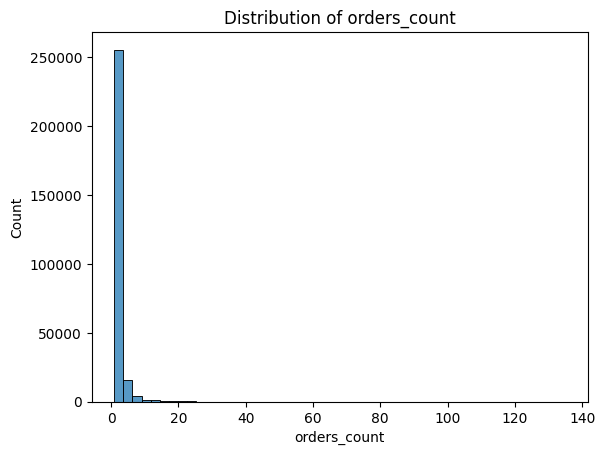

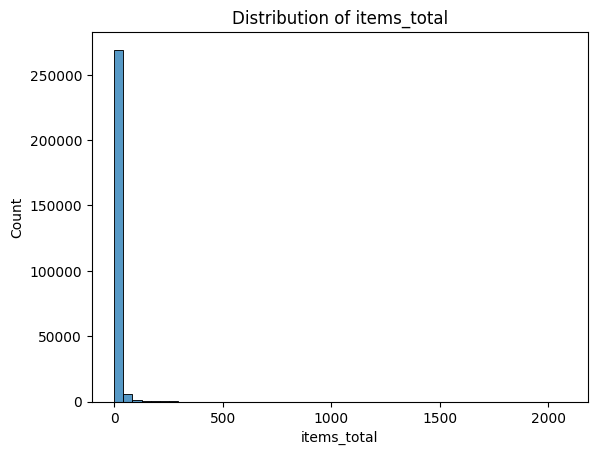

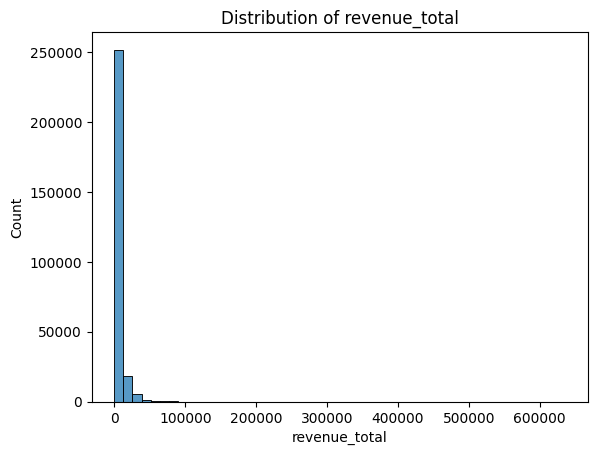

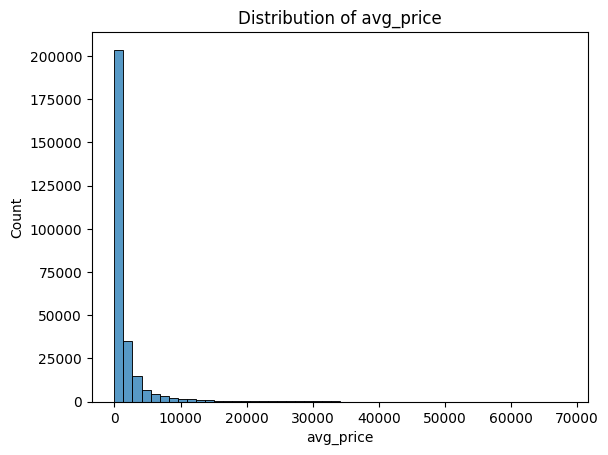

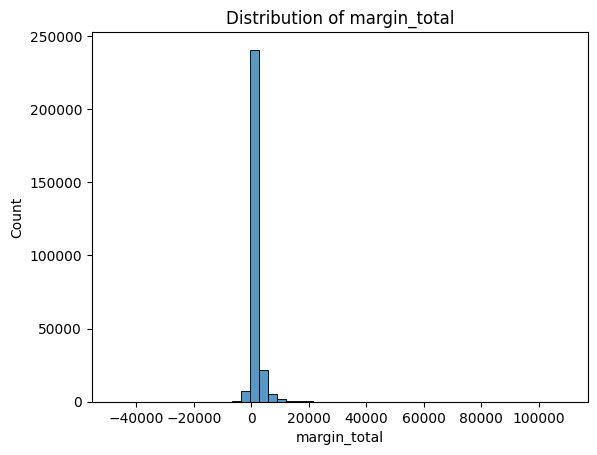

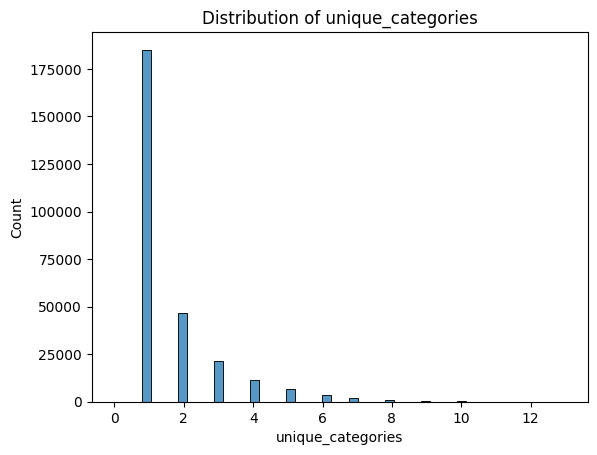

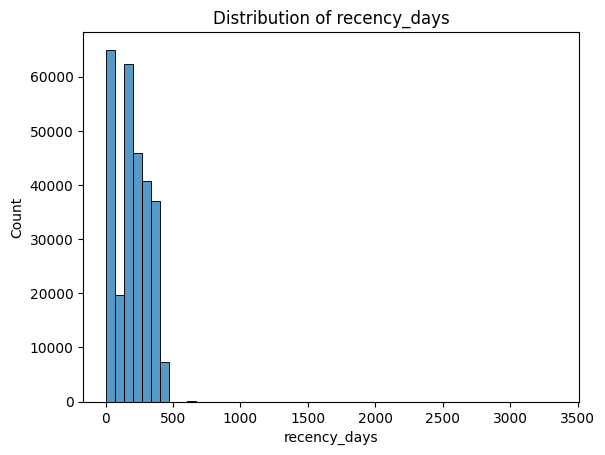

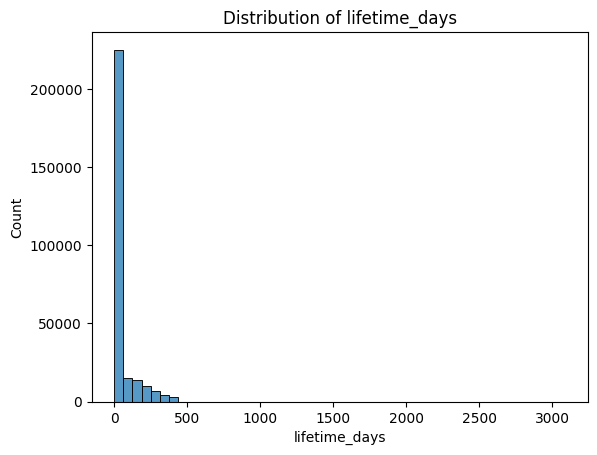

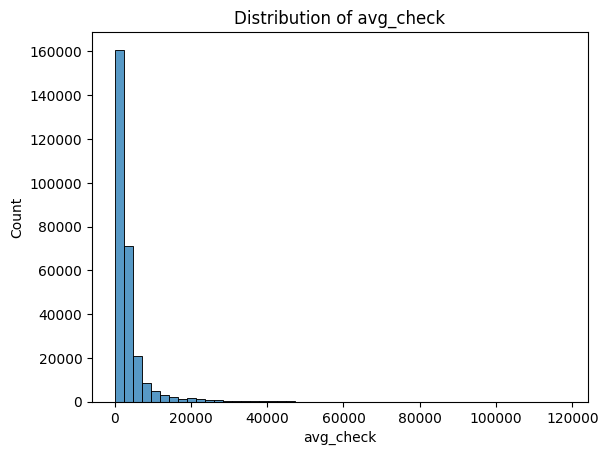

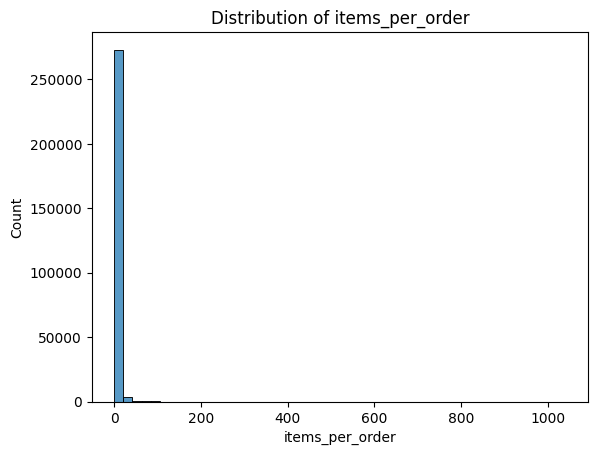

In [71]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(client_df[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

In [72]:
#Логарифмируем колонки
log_cols = [
    'orders_count',
    'revenue_total',
    'items_total',
    'avg_check',
    'avg_price',
    'items_per_order'
]

for col in log_cols:
    client_df[col] = np.log1p(client_df[col])

In [73]:
for col in log_cols:
    print(col, client_df[col].min())

orders_count 0.6931471805599453
revenue_total 0.6931471805599453
items_total 0.6931471805599453
avg_check 0.6931471805599453
avg_price 0.6931471805599453
items_per_order 0.6931471805599453


In [74]:
print(client_df[numeric_cols].skew())

orders_count         2.356365
items_total          1.407393
revenue_total        0.157143
avg_price            0.523878
margin_total         5.362629
unique_categories    2.463283
recency_days         0.751316
lifetime_days        2.594424
avg_check            0.239312
items_per_order      1.566492
dtype: Float64


In [75]:
client_df['margin_total'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count    277833.000000
mean        985.677910
std        1883.067609
min      -47658.270000
50%         424.310000
90%        2656.624000
95%        4194.128000
99%        8835.722000
99.9%     16559.472080
max      109256.640000
Name: margin_total, dtype: float64

In [76]:
#Для margin_total обрежем хвост
lower = client_df['margin_total'].quantile(0.005)
upper = client_df['margin_total'].quantile(0.995)

client_df['margin_total'] = np.clip(
    client_df['margin_total'],
    lower,
    upper
)

In [77]:
client_df['margin_total'].skew()

np.float64(3.125847137279546)

In [78]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277833 entries, 0 to 277832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277833 non-null  object 
 1   orders_count       277833 non-null  float64
 2   items_total        277833 non-null  Float64
 3   revenue_total      277833 non-null  float64
 4   avg_price          277833 non-null  float64
 5   margin_total       277833 non-null  float64
 6   unique_categories  277833 non-null  int64  
 7   recency_days       277833 non-null  int64  
 8   lifetime_days      277833 non-null  int64  
 9   avg_check          277833 non-null  float64
 10  items_per_order    277833 non-null  Float64
 11  Месяц_Год          277833 non-null  object 
dtypes: Float64(2), float64(5), int64(3), object(2)
memory usage: 26.0+ MB


In [79]:
num_cols = client_df.select_dtypes(include=['int', 'float']).columns

In [80]:
num_cols

Index(['orders_count', 'items_total', 'revenue_total', 'avg_price',
       'margin_total', 'unique_categories', 'recency_days', 'lifetime_days',
       'avg_check', 'items_per_order'],
      dtype='object')

In [81]:
corr_matrix = client_df[num_cols].corr(method='pearson')

corr_matrix.round(2)

,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order
orders_count,1.00,0.74,0.53,-0.14,0.31,0.70,-0.25,0.80,0.03,0.26
items_total,0.74,1.00,0.42,-0.47,0.17,0.74,-0.23,0.60,0.04,0.84
revenue_total,0.53,0.42,1.00,0.59,0.66,0.43,-0.13,0.43,0.86,0.16
avg_price,-0.14,-0.47,0.59,1.00,0.49,-0.22,0.09,-0.11,0.79,-0.57
margin_total,0.31,0.17,0.66,0.49,1.00,0.26,-0.01,0.23,0.60,-0.00
unique_categories,0.70,0.74,0.43,-0.22,0.26,1.00,-0.18,0.58,0.09,0.50
recency_days,-0.25,-0.23,-0.13,0.09,-0.01,-0.18,1.00,-0.32,-0.01,-0.13
lifetime_days,0.80,0.60,0.43,-0.11,0.23,0.58,-0.32,1.00,0.02,0.21
avg_check,0.03,0.04,0.86,0.79,0.60,0.09,-0.01,0.02,1.00,0.03
items_per_order,0.26,0.84,0.16,-0.57,-0.00,0.50,-0.13,0.21,0.03,1.00


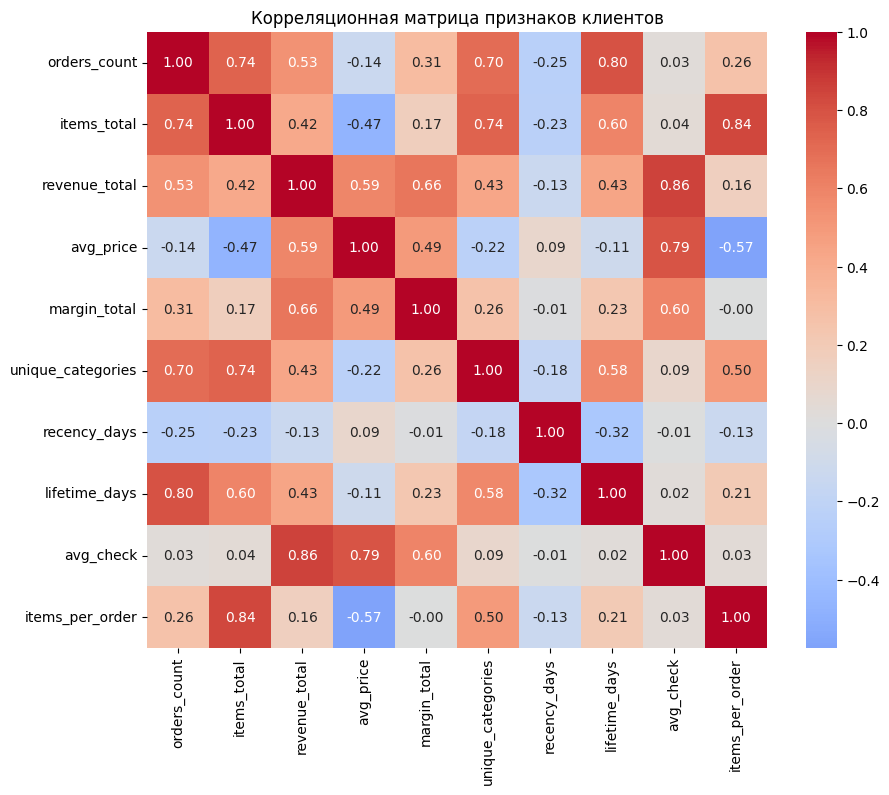

In [82]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Корреляционная матрица признаков клиентов")
plt.show()

In [83]:
features = [
    'orders_count',
    'items_per_order',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days'
]

In [84]:
X = client_df[features].copy()

In [85]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

In [86]:
X_kmeans = X_scaled.copy()
X_em = X_scaled.copy()
X_hdbscan = X_scaled.copy()

In [87]:
inertia = []
ch_scores = []
db_scores = []

K_range = range(2, 20)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_kmeans)

    inertia.append(kmeans.inertia_)

    ch_scores.append(
        calinski_harabasz_score(X_kmeans, labels)
    )

    db_scores.append(
        davies_bouldin_score(X_kmeans, labels)
    )

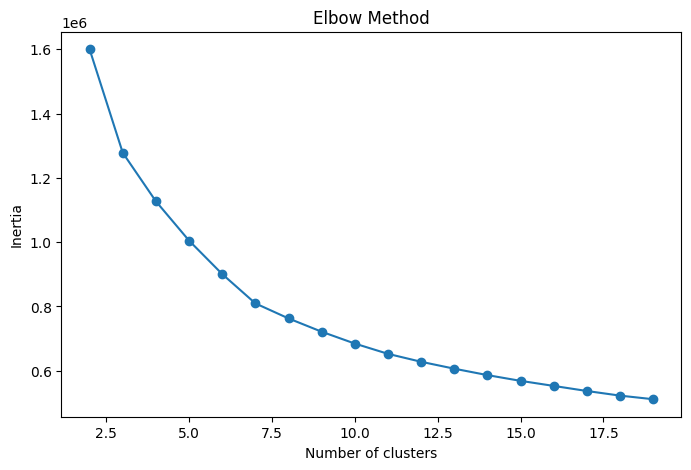

In [88]:
#метод локтя
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

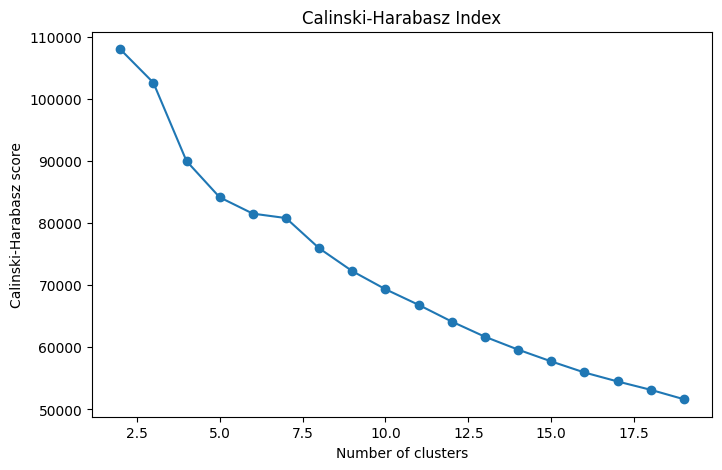

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, ch_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz score')
plt.title('Calinski-Harabasz Index')

plt.show()

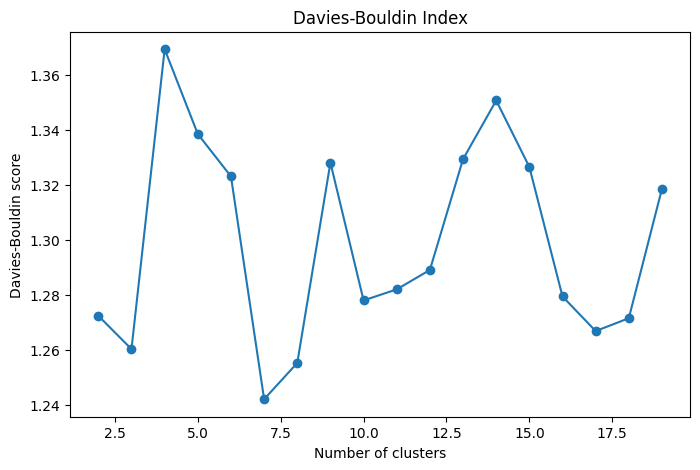

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, db_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin Index')

plt.show()

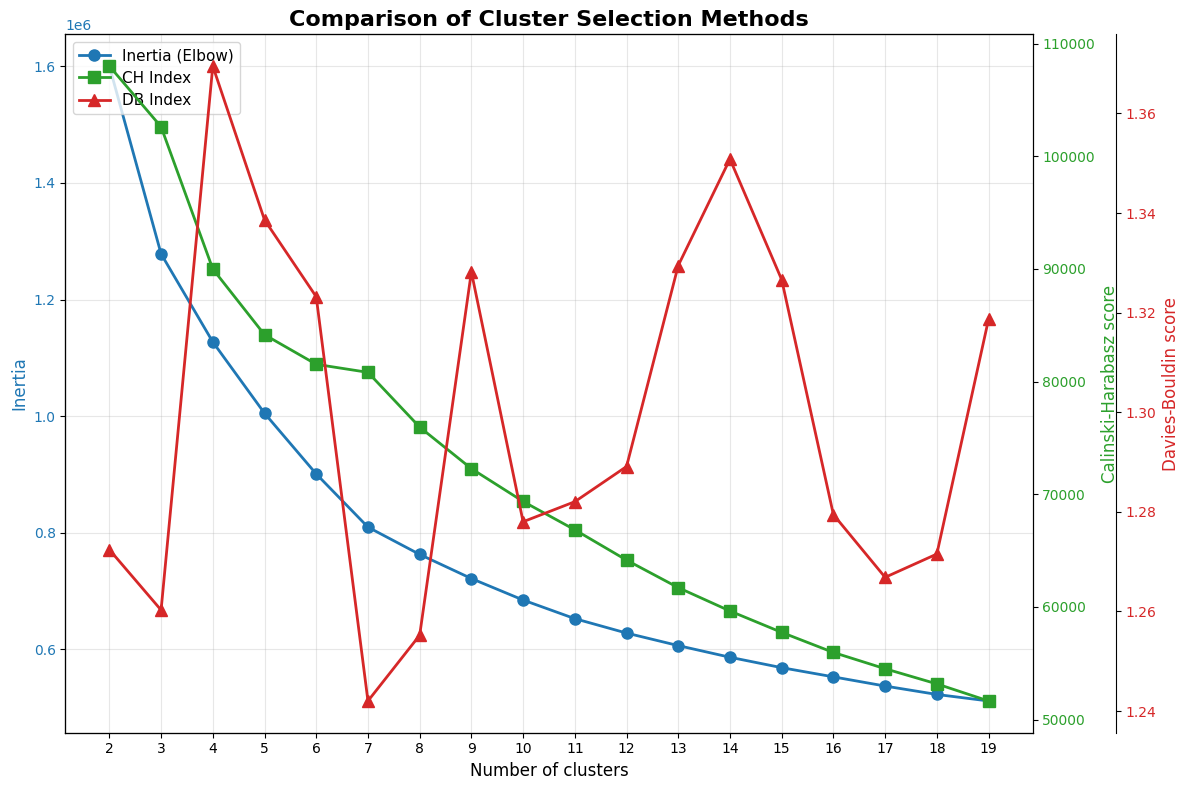

In [91]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.set_xticks(K_range)
color = 'tab:blue'
ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Inertia', color=color, fontsize=12)
line1 = ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2, markersize=8, label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Calinski-Harabasz score', color=color, fontsize=12)
line2 = ax2.plot(K_range, ch_scores, marker='s', color=color, linewidth=2, markersize=8, label='CH Index')
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:red'
ax3.set_ylabel('Davies-Bouldin score', color=color, fontsize=12)
line3 = ax3.plot(K_range, db_scores, marker='^', color=color, linewidth=2, markersize=8, label='DB Index')
ax3.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Comparison of Cluster Selection Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
metrics_df = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertia,
    'calinski_harabasz': ch_scores,
    'davies_bouldin': db_scores
})

metrics_df

,k,inertia,calinski_harabasz,davies_bouldin
0,2,1.600506e+06,108000.231053,1.272422
1,3,1.278373e+06,102612.015040,1.260282
2,4,1.127279e+06,89989.832887,1.369520
3,5,1.004990e+06,84156.199812,1.338632
4,6,9.008659e+05,81528.738184,1.323198
5,7,8.096303e+05,80814.428709,1.242026
6,8,7.628254e+05,75954.761502,1.255225
7,9,7.214098e+05,72269.303853,1.328195
8,10,6.845724e+05,69356.821378,1.278017
9,11,6.526030e+05,66839.754923,1.282045


* Davies-Bouldin - минимальное значение при k=7
* Elbow method - после 7 снижение инерции замедляется
* Calinski-Harabasz - хотя пик при k=3, после 7 падение стабилизируется

Исходя из этого, оптимальным выбором будет k=7

# K-means

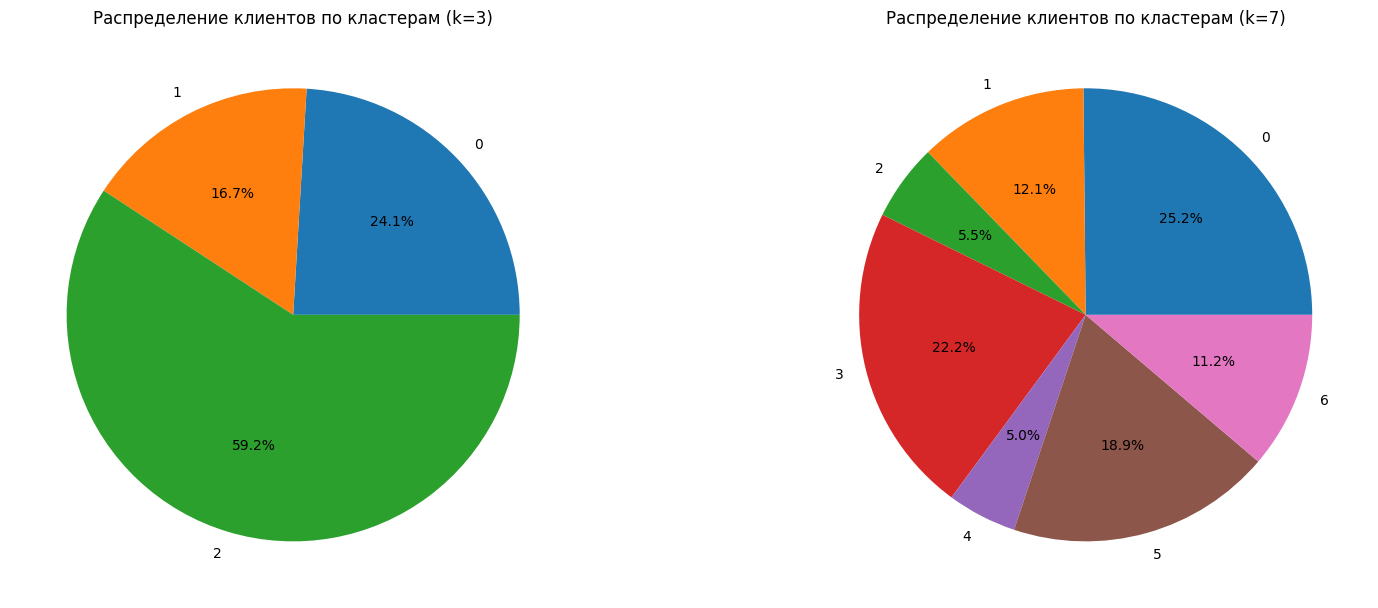

In [94]:
k_values = [3, 7]

plt.figure(figsize=(16, 12))

for i, k in enumerate(k_values, 1):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_kmeans)
    
    cluster_counts = (
        pd.Series(clusters)
        .value_counts()
        .sort_index()
    )
    
    client_df[f'cluster_{k}'] = clusters
    plt.subplot(2, 2, i)
    plt.pie(
        cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%'
    )
    
    plt.title(f'Распределение клиентов по кластерам (k={k})')

plt.tight_layout()
plt.show()

In [95]:
#Составим портрет кластеров
def cluster_profile(df, features, cluster_col):
    
    # агрегаты по признакам
    profile = df.groupby(cluster_col)[features].agg(['mean', 'median']).round(2)
    
    # количество клиентов
    counts = df[cluster_col].value_counts().sort_index()
    total = len(df)
    
    # процент от общего числа
    share = (counts / total * 100).round(2)
    
    # добавляем в таблицу
    profile[('cluster_size', 'count')] = counts
    profile[('cluster_size', 'share_%')] = share
    
    return profile

In [96]:
cluster_col = 'cluster_7'

profile_7 = cluster_profile(client_df, features, cluster_col)

display(profile_7)

orders_count        items_per_order        revenue_total         \
                  mean median            mean median          mean median   
cluster_7                                                                   
0                 0.72   0.69            1.29    1.1          6.82   6.90   
1                 1.37   1.39            1.46   1.39          8.65   8.66   
2                 0.85   0.69            1.04    1.1          9.83   9.84   
3                 0.74   0.69            1.19    1.1          7.61   7.62   
4                 2.00   1.95            2.03   1.95          9.73   9.71   
5                 0.75   0.69            0.98    1.1          8.34   8.29   
6                 0.86   0.69            2.46    2.3          8.11   8.10   

          avg_price        margin_total          unique_categories         \
               mean median         mean   median              mean median   
cluster_7                                                                   
0              5.81   5.87       192.06   157.68              1.15    1.0   
1              6.41   6.39       941.30   776.22              2.41    2.0   
2              9.03   9.11      5600.92  4873.12              1.33    1.0   
3              6.71   6.69       335.91   258.00              1.15    1.0   
4              6.12   6.08      3189.78  2494.65              5.32    5.0   
5              7.78   7.75      1061.34   919.00              1.14    1.0   
6              5.55   5.61       645.68   465.10              2.54    2.0   

          recency_days        lifetime_days        cluster_size          
                  mean median          mean median        count share_%  
cluster_7                                                                
0               272.86  273.0          2.99    0.0        69897   25.16  
1               123.66  134.0        174.23  161.0        33608   12.10  
2               217.31  223.0         21.21    0.0        15187    5.47  
3                75.27   42.0          3.04    0.0        61659   22.19  
4                94.11   46.0        244.38  242.0        13810    4.97  
5               285.88  293.0          4.41    0.0        52520   18.90  
6               199.74  197.0         16.94    0.0        31152   11.21

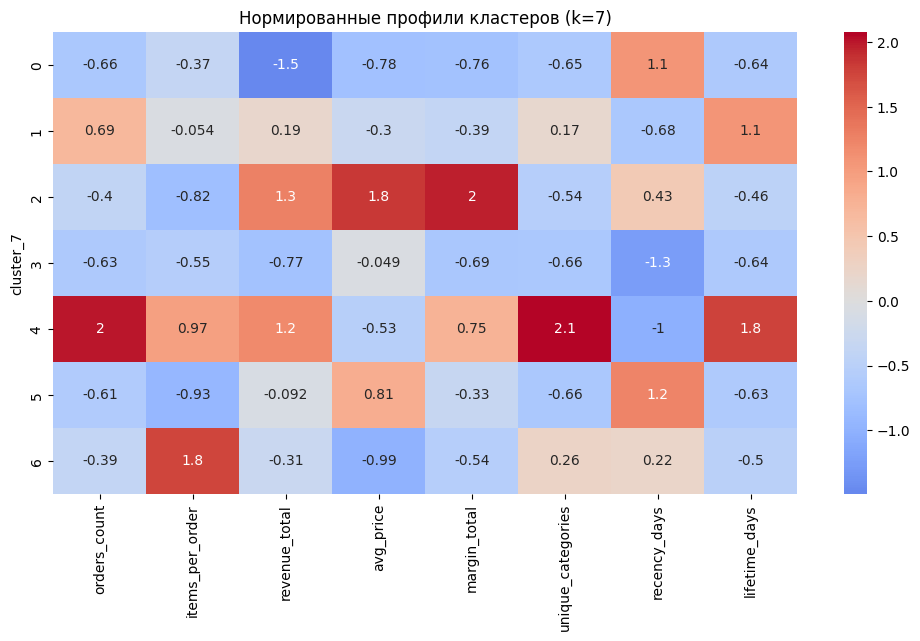

In [97]:
means = client_df.groupby('cluster_7')[features].mean().astype(float)

means_scaled = (means - means.mean()) / means.std()

plt.figure(figsize=(12,6))
sns.heatmap(means_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров (k=7)")
plt.show()

* ordes_count — количество заказов
* items_per_order — товаров в заказе
* revenue_total — общая выручка
* avg_price — средний чек / цена
* margin_total — общая маржинальность
* unique_categories — уникальных категорий
* recent_days — давность последней покупки (чем меньше, тем лучше / активнее)
* lifetime_days — длительность жизни клиента

**Кластер 0**
* Минимальное количество категорий (-1.5), низкая маржа (-0.76), низкий средний чек (-0.78)
* Высокая давность (1.1) — давно не покупали
* Спящие / отточные клиенты с узким ассортиментом

**Кластер 1**
* Высокий lifetime_days (1.1), выше среднего заказы (0.69), средний чек чуть ниже (-0.3)
* Недавно покупали (-0.68)
* Стабильные старые клиенты
  
**Кластер 2**
* Очень высокий avg_price (1.8), высокая маржа (2.0), много категорий (1.3)
* Низкая частота заказов (-0.4) и низкая давность (0.42 — плохо)
* Дорогие, но редкие клиенты — возможно, премиум, но теряют активность

**Кластер 3**
* ВСЕ признаки сильно ниже среднего (почти все отрицательные, кроме avg_price близкого к 0)
* Очень низкая давность (-1.2) — давно не покупали
* Кандидаты на отток — неактивные, с низкими показателями

**Кластер 4**
* Очень высокая частота заказов (2.0) и высокий средний чек (1.2), высокая маржа (0.73), много категорий (2.1)
* Недавно покупали 
* Частые, дорогие, маржинальные, лояльные

**Кластер 5**
* Выше среднего avg_price (0.82), выше среднего lifetime_days (1.2)
* Остальное — ниже среднего
* Скорее всего — клиенты с высоким чеком, но редкими покупками, старые

**Кластер 6**
* Очень низкие заказы (-0.39), низкий средний чек (-0.99), низкая маржа (-0.54)
* Высокое items_per_order (1.8) — покупают много товаров за раз, но редко
* Слабая давность (0.25) — давно не покупали
* Скорее всего — редкие, но оптовые/семейные покупатели с низкой маржой


**Итог**
* Топ (частые, дорогие) -	4
* Дорогие, но редкие	- 2, 5
* Массовые / средние - 1
* Редкие / оптовые - 6
* Отточные / неактивные - 3, 0

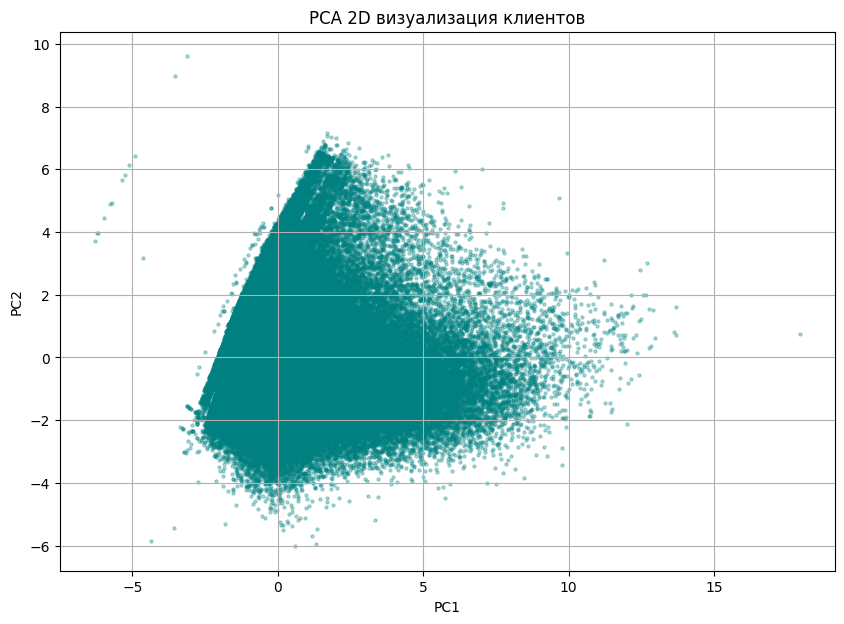

Доля объясненной дисперсии: PC1 = 0.40, PC2 = 0.27, PC1+PC2 = 0.67


In [98]:
#PCA
X_plot = X_kmeans.copy() 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_plot)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Визуализация
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=5, alpha=0.3, color='teal')
plt.title('PCA 2D визуализация клиентов')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

explained_var = pca.explained_variance_ratio_
print(f"Доля объясненной дисперсии: PC1 = {explained_var[0]:.2f}, PC2 = {explained_var[1]:.2f}, PC1+PC2 = {explained_var[0]+explained_var[1]:.2f}")

# HDBSCAN


Распределение клиентов по кластерам (HDBSCAN):
cluster_hdbscan
-1     46913
 0     61299
 1      1496
 2      5416
 3     19665
 4      6682
 5     26750
 6     66000
 7      3530
 8     13979
 9     13653
 10      607
 11     1187
 12     1011
 13     4563
 14     5082
Name: count, dtype: int64
Процент клиентов, относящихся к шуму: 16.89%


/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_1318/2113261620.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)


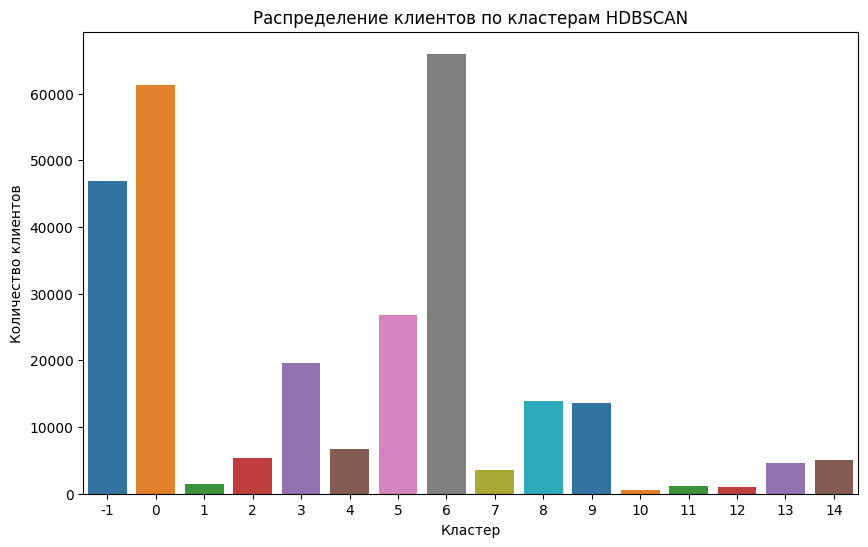

In [99]:
# Настройка HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,   # минимальный размер кластера
    min_samples=50,         # чувствительность к шуму
    metric='euclidean',
    cluster_selection_method='eom'
)

# Обучаем модель
cluster_labels = clusterer.fit_predict(X_hdbscan)

# Добавляем метки в датафрейм клиентов
client_clusters = client_df.copy()
client_clusters['cluster_hdbscan'] = cluster_labels

# Посмотрим распределение по кластерам
cluster_counts = client_clusters['cluster_hdbscan'].value_counts().sort_index()
print("Распределение клиентов по кластерам (HDBSCAN):")
print(cluster_counts)

# Процент клиентов, которые HDBSCAN считает шумом (-1)
noise_pct = (cluster_counts.get(-1, 0) / len(client_clusters)) * 100
print(f"Процент клиентов, относящихся к шуму: {noise_pct:.2f}%")

# Визуализация распределения кластеров
plt.figure(figsize=(10,6))
sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)
plt.title('Распределение клиентов по кластерам HDBSCAN')
plt.xlabel('Кластер')
plt.ylabel('Количество клиентов')
plt.show()

/Users/ekaterinazinoveva/Mag/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


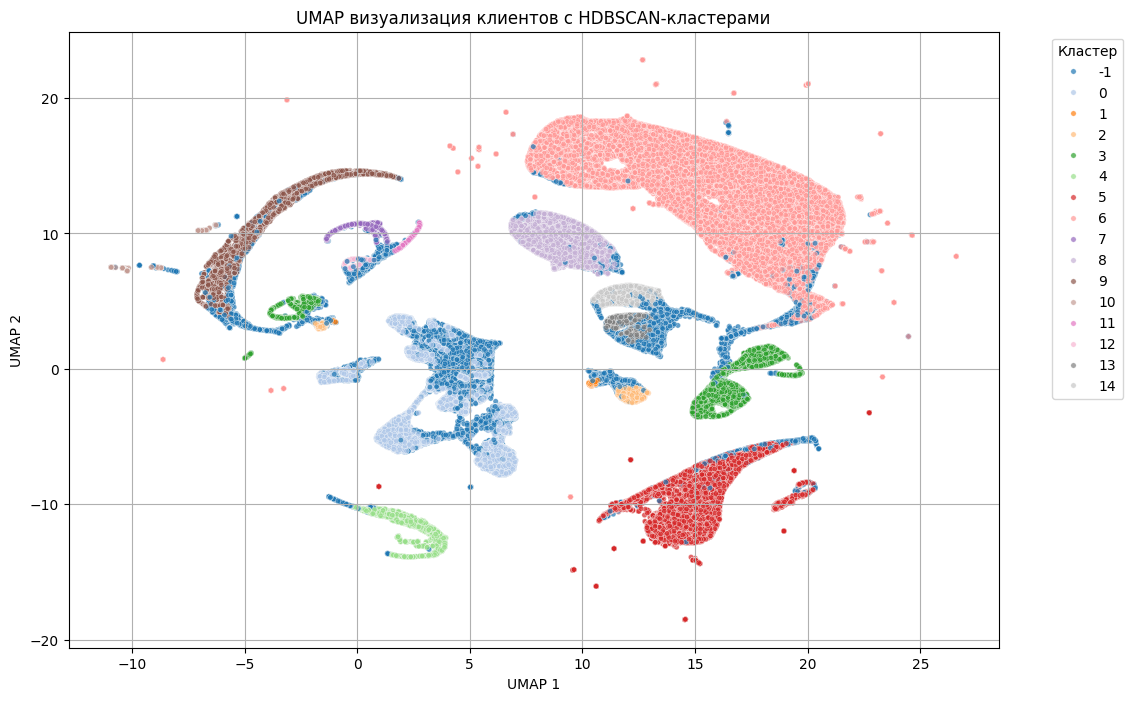

In [81]:
X_umap = X_scaled.copy() 

# UMAP
reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=50,       
    min_dist=0.0,         
    metric='euclidean', 
    random_state=42
)
X_embedded = reducer.fit_transform(X_umap)

umap_df = pd.DataFrame(X_embedded, columns=['UMAP1', 'UMAP2'])
umap_df['cluster'] = client_clusters['cluster_hdbscan'].values

plt.figure(figsize=(12,8))
palette = sns.color_palette("tab20", n_colors=len(umap_df['cluster'].unique()))
sns.scatterplot(
    x='UMAP1', y='UMAP2', 
    hue='cluster', 
    data=umap_df, 
    palette=palette,
    legend='full',
    s=15,
    alpha=0.7
)
plt.title('UMAP визуализация клиентов с HDBSCAN-кластерами')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

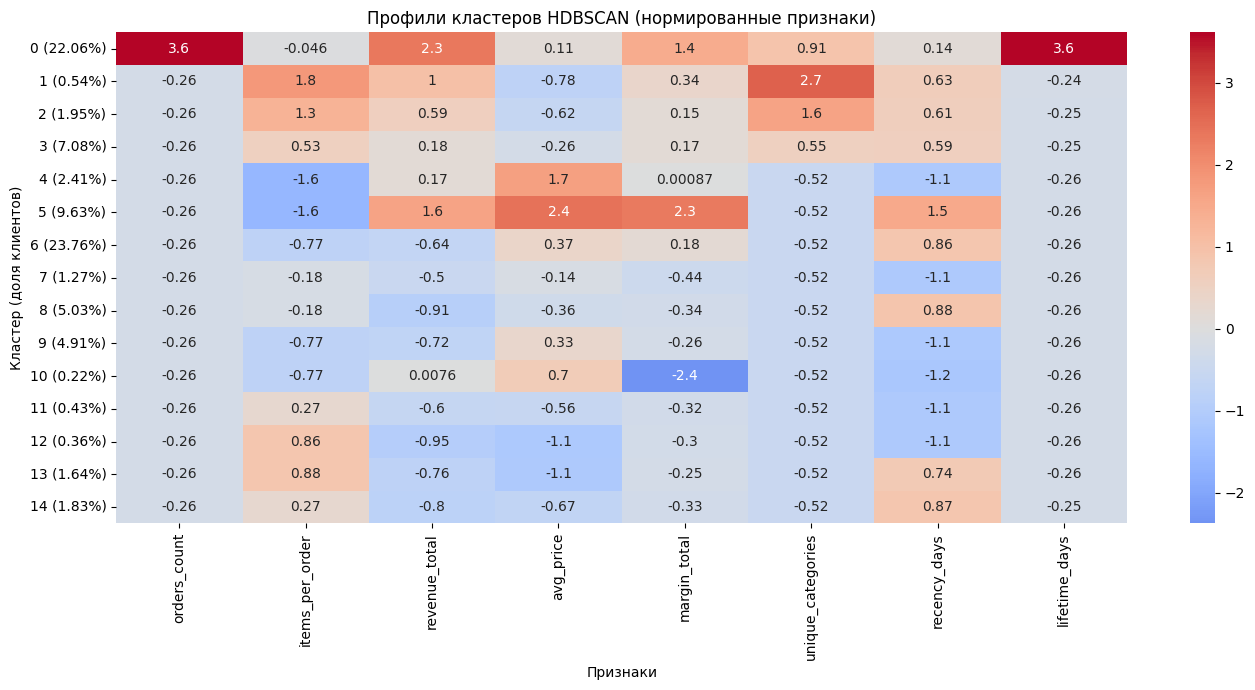

In [100]:
# убираем шум
df_hdb = client_clusters[client_clusters['cluster_hdbscan'] != -1].copy()

# средние значения
means_hdb = df_hdb.groupby('cluster_hdbscan')[features].mean().astype(float)

# нормализация ПО СТОЛБЦАМ
means_scaled = (means_hdb - means_hdb.mean()) / means_hdb.std()

# доля клиентов (без шума)
cluster_sizes = df_hdb['cluster_hdbscan'].value_counts().sort_index()
cluster_share = (cluster_sizes / len(client_clusters) * 100).round(2)

# добавляем % в название кластера
new_index = [
    f"{cluster} ({cluster_share[cluster]}%)"
    for cluster in means_scaled.index
]

means_scaled.index = new_index

plt.figure(figsize=(14, 7))

sns.heatmap(
    means_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Профили кластеров HDBSCAN (нормированные признаки)")
plt.xlabel("Признаки")
plt.ylabel("Кластер (доля клиентов)")
plt.tight_layout()
plt.show()

Кластер 0 (22,06%) имеет максимальные значения по количеству заказов (+3,61) и длительности жизни клиента (+3,61). Кластер 1 (0,54%) показывает наибольшую широту категорий (+2,69) и количество товаров в заказе (+1,83). Кластер 5 (9,63%) лидирует по среднему чеку (+2,43) и маржинальности (+2,31). При этом кластер 10 (0,22%) имеет минимальную маржинальность (-2,37), а кластеры 7, 9, 10, 11, 12 демонстрируют самые низкие показатели давности покупки (от -1,11 до -1,20), что указывает на давно неактивных клиентов.

# EM-кластеризация

In [104]:
#Подбор числа кластеров
K_range = range(2, 15)
bic_scores = []
aic_scores = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_em)
    
    bic_scores.append(gmm.bic(X_em))
    aic_scores.append(gmm.aic(X_em))

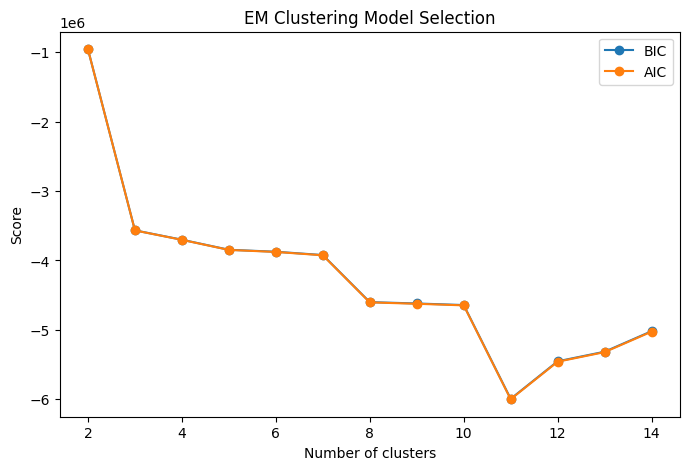

In [105]:
#Оптимальное число кластеров - BIC/AIC минимальны
plt.figure(figsize=(8,5))
plt.plot(K_range, bic_scores, marker='o', label='BIC')
plt.plot(K_range, aic_scores, marker='o', label='AIC')

plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.title('EM Clustering Model Selection')
plt.legend()

plt.show()

In [130]:
#Подбираем лучший тип ковариации
covariance_types = ['full', 'tied', 'diag', 'spherical']
best_score = -1
best_params = {}

for cov_type in covariance_types:
    # Подбираем число кластеров для каждого типа
    K_range = range(2, 15)
    bic_scores = []
    
    for k in K_range:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type, 
                             random_state=42, n_init=10)
        gmm.fit(X_em)
        bic_scores.append(gmm.bic(X_em))
    
    optimal_k = K_range[np.argmin(bic_scores)]
    
    # Оцениваем качество
    gmm = GaussianMixture(n_components=optimal_k, covariance_type=cov_type, 
                         random_state=42, n_init=10)
    clusters = gmm.fit_predict(X_em)
    score = silhouette_score(X_em, clusters)
    
    print(f"{cov_type}: k={optimal_k}, silhouette={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = {'cov_type': cov_type, 'n_components': optimal_k}


full: k=12, silhouette=-0.0267
tied: k=14, silhouette=0.1648
diag: k=13, silhouette=0.0260
spherical: k=14, silhouette=0.1571


In [131]:
gmm = GaussianMixture(
    n_components=14,  
    covariance_type='tied',
    random_state=42,
    n_init=10,
    max_iter=500
)
clusters_em = gmm.fit_predict(X_em)
client_df['cluster_em'] = clusters_em

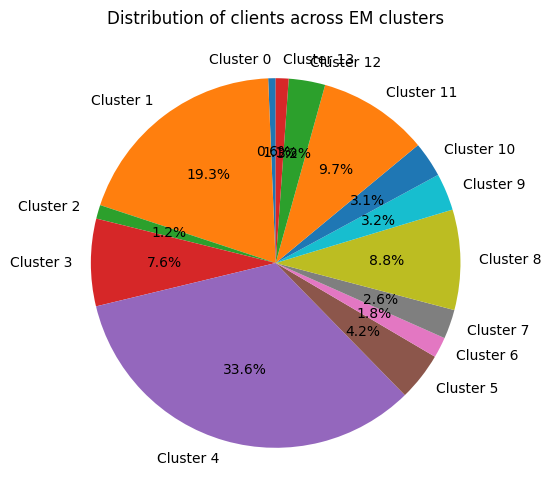

In [132]:
cluster_counts_em = client_df['cluster_em'].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.pie(cluster_counts_em,
        labels=[f'Cluster {i}' for i in cluster_counts_em.index],
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of clients across EM clusters')
plt.show()

In [133]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277833 entries, 0 to 277832
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277833 non-null  object 
 1   orders_count       277833 non-null  float64
 2   items_total        277833 non-null  Float64
 3   revenue_total      277833 non-null  float64
 4   avg_price          277833 non-null  float64
 5   margin_total       277833 non-null  float64
 6   unique_categories  277833 non-null  int64  
 7   recency_days       277833 non-null  int64  
 8   lifetime_days      277833 non-null  int64  
 9   avg_check          277833 non-null  float64
 10  items_per_order    277833 non-null  Float64
 11  Месяц_Год          277833 non-null  object 
 12  cluster_7          277833 non-null  int32  
 13  cluster_em         277833 non-null  int64  
 14  cluster_hdbscan    277833 non-null  int64  
dtypes: Float64(2), float64(5), int32(1), int64(5), obje

In [134]:
cols_to_drop = ['cluster_3','cluster_7']
numeric_df = client_df.select_dtypes(include='number').drop(columns=cols_to_drop, errors='ignore')

In [135]:
cluster_profiles = numeric_df.groupby('cluster_em').mean()

In [136]:
print(cluster_profiles.dtypes)

orders_count         float64
items_total          Float64
revenue_total        float64
avg_price            float64
margin_total         float64
unique_categories    float64
recency_days         float64
lifetime_days        float64
avg_check            float64
items_per_order      Float64
cluster_hdbscan      float64
dtype: object


In [137]:
cluster_profiles = cluster_profiles.astype(float)

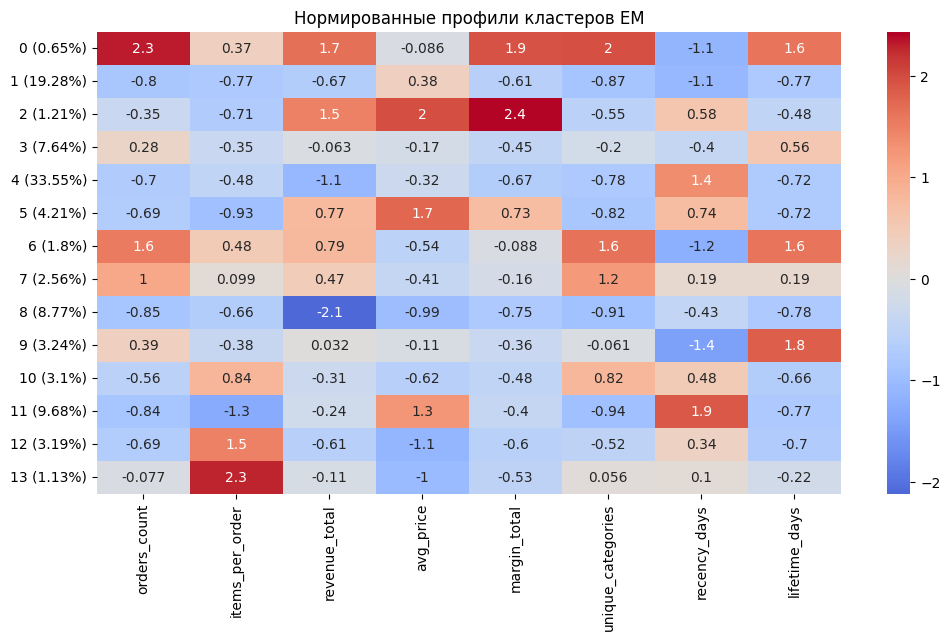

In [138]:

cluster_em_sizes = client_df['cluster_em'].value_counts().sort_index()
cluster_em_share = (cluster_em_sizes / len(client_df) * 100).round(2)

means_em = client_df.groupby('cluster_em')[features].mean().astype(float)

means_em.index = [f"{cluster} ({cluster_em_share[cluster]}%)" for cluster in means_em.index]

means_em_scaled = (means_em - means_em.mean()) / means_em.std()

# Тепловая карта
plt.figure(figsize=(12,6))
sns.heatmap(means_em_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров EM")
plt.show()

In [139]:
means_em_scaled.to_excel('тепловая_карта_EM.xlsx')

Файл 'тепловая_карта_EM.xlsx' успешно сохранен!


**Кластер 0 (0.65%)** — элитный сегмент: максимальные заказы (+2.31), высокая выручка (+1.66), максимальная маржинальность (+1.94), широкий ассортимент (+1.95), свежие покупки (-1.13), давние клиенты (+1.63).

**Кластер 1 (19.28%)** — массовый неактивный сегмент: низкие заказы (-0.80), выручка (-0.67), маржинальность (-0.61), узкий ассортимент (-0.87), но недавно активны (-1.07).

**Кластер 2 (1.21%)** — премиум-сегмент: максимальный средний чек (+1.99), максимальная маржинальность (+2.43), высокая выручка (+1.48), узкий ассортимент (-0.55).

**Кластер 3 (7.64%)** — средний сегмент: показатели близки к средним, небольшая длительность жизни (+0.56).

**Кластер 4 (33.55%)** — самый крупный спящий сегмент: минимальная выручка (-1.08), мало заказов (-0.70), узкий ассортимент (-0.78), высокая давность покупок (+1.36).

**Кластер 5 (4.21%)** — премиум-сегмент: высокий средний чек (+1.75), высокая маржинальность (+0.73), мало товаров в заказе (-0.93).

**Кластер 6 (1.8%)** — активный сегмент: много заказов (+1.55), широкий ассортимент (+1.64), свежие покупки (-1.21), давние клиенты (+1.63).

**Кластер 7 (2.56%)** — активный сегмент: хорошие заказы (+1.03), широкий ассортимент (+1.19), средние показатели по остальным метрикам.

**Кластер 8 (8.77%)** — проблемный сегмент: минимальная выручка (-2.12), самый низкий средний чек (-0.99), крайне низкие показатели по всем метрикам.

**Кластер 9 (3.24%)** — лояльный сегмент: максимальная длительность жизни (+1.81), самые свежие покупки (-1.44), средние заказы.

**Кластер 10 (3.1%)** — нишевый сегмент: много товаров в заказе (+0.84), широкий ассортимент (+0.82), низкая выручка.

**Кластер 11 (9.68%)** — ушедший сегмент: максимальная давность покупок (+1.89), мало товаров в заказе (-1.27), узкий ассортимент (-0.94).

**Кластер 12 (3.19%)** — нишевый сегмент: очень много товаров в заказе (+1.48), низкий средний чек (-1.12).

**Кластер 13 (1.13%)** — нишевый сегмент: максимальное количество товаров в заказе (+2.28), низкий средний чек (-1.02).

In [140]:
# KMeans (k=7)
sil_kmeans = silhouette_score(X_kmeans, client_df['cluster_7'])
print("Silhouette KMeans:", sil_kmeans)

# HDBSCAN (без шума)
mask_hdb = client_clusters['cluster_hdbscan'] != -1
sil_hdb = silhouette_score(
    X_hdbscan[mask_hdb],
    client_clusters.loc[mask_hdb, 'cluster_hdbscan']
)
print("Silhouette HDBSCAN:", sil_hdb)


# EM (Gaussian Mixture)
sil_em = silhouette_score(X_em, client_df['cluster_em'])
print("Silhouette EM:", sil_em)

Silhouette KMeans: 0.22828468607901586
Silhouette HDBSCAN: -0.025058858658512557
Silhouette EM: 0.1648167718846919


In [125]:
client_df['cluster_hdbscan'] = client_clusters['cluster_hdbscan']

In [126]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,Месяц_Год,cluster_3,cluster_7,cluster_em,cluster_hdbscan
0,32555749-545749525150 .,0.693147,1.94591,6.993015,5.205837,174.66,1,327,0,6.993015,1.94591,"[2017-04, 2017-04, 2017-04, 2017-04, 2017-04, ...",2,0,3,13
1,49574954-56524849545119,0.693147,1.098612,8.559486,7.866531,-704.86,1,191,0,8.559486,1.098612,"[2017-08, 2017-08]",0,5,10,6
2,51534957-48525550515032,0.693147,1.609438,7.000334,5.521461,262.00,1,233,0,7.000334,1.609438,"[2017-07, 2017-07, 2017-07]",2,0,2,14
3,55494851-56495152535476,0.693147,0.693147,7.396949,7.396949,376.02,1,343,0,7.396949,0.693147,[2017-03],0,5,0,5
4,55515349-57484951525673,0.693147,0.693147,7.204893,7.204893,-186.00,1,181,0,7.204893,0.693147,[2017-08],2,3,0,5


In [128]:
client_df = client_df.drop(columns=['cluster_3'])

In [129]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277833 entries, 0 to 277832
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Телефон_new        277833 non-null  object 
 1   orders_count       277833 non-null  float64
 2   items_total        277833 non-null  Float64
 3   revenue_total      277833 non-null  float64
 4   avg_price          277833 non-null  float64
 5   margin_total       277833 non-null  float64
 6   unique_categories  277833 non-null  int64  
 7   recency_days       277833 non-null  int64  
 8   lifetime_days      277833 non-null  int64  
 9   avg_check          277833 non-null  float64
 10  items_per_order    277833 non-null  Float64
 11  Месяц_Год          277833 non-null  object 
 12  cluster_7          277833 non-null  int32  
 13  cluster_em         277833 non-null  int64  
 14  cluster_hdbscan    277833 non-null  int64  
dtypes: Float64(2), float64(5), int32(1), int64(5), obje

In [145]:
df_time = client_df[['Телефон_new','Месяц_Год','cluster_7','cluster_em']].copy()
df_time = df_time.explode('Месяц_Год')
df_time['Месяц_Год'] = pd.PeriodIndex(df_time['Месяц_Год'], freq='M')

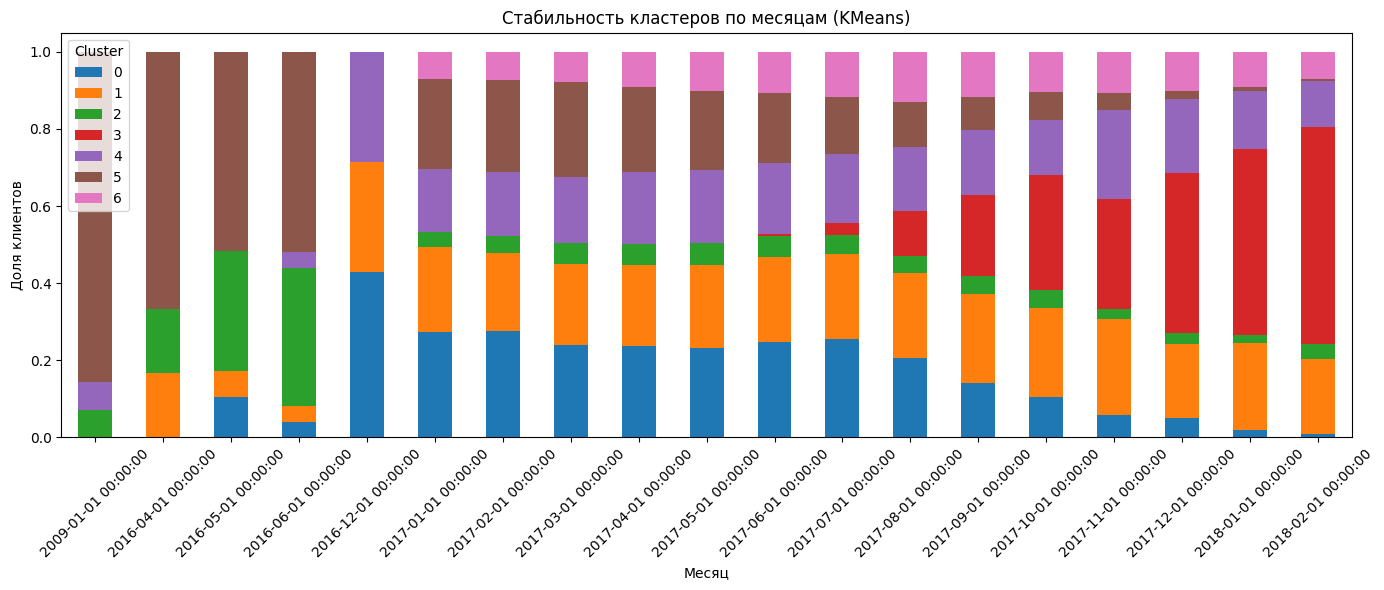

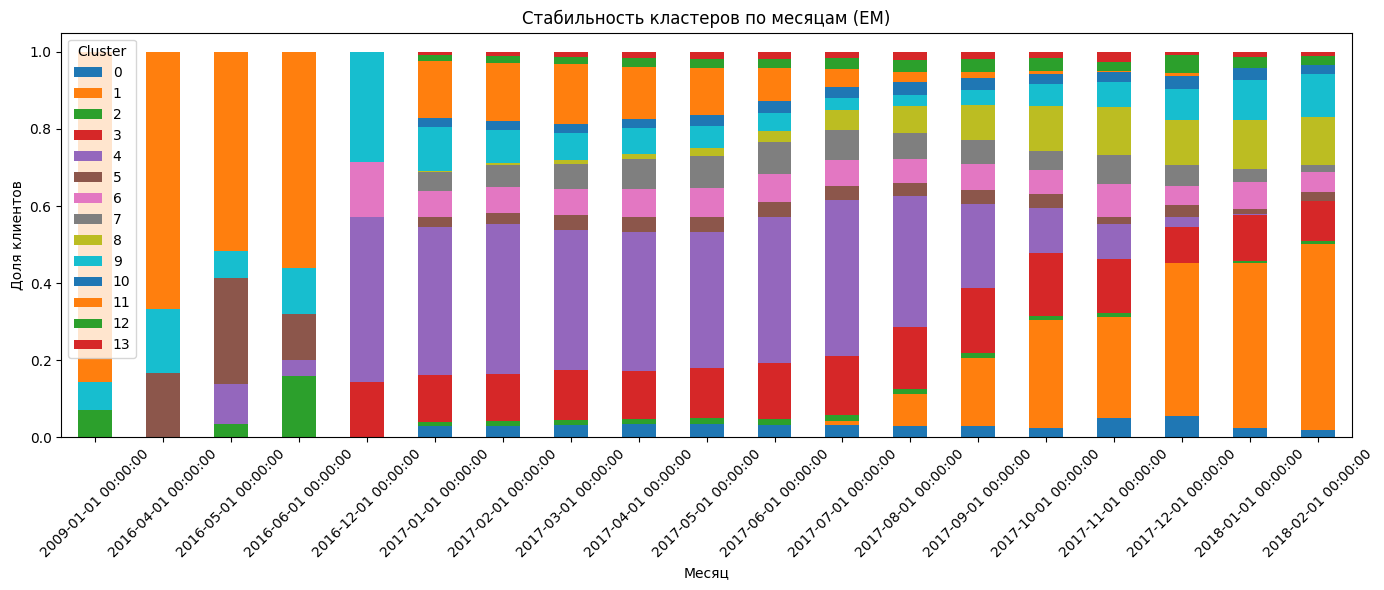

In [147]:
df_time = client_df[['Телефон_new','Месяц_Год','cluster_7','cluster_em']].copy()
df_time = df_time.explode('Месяц_Год')
df_time['Месяц_Год'] = pd.to_datetime(df_time['Месяц_Год'].astype(str))

#K-means

kmeans_month = (
    df_time.groupby(['Месяц_Год','cluster_7'])['Телефон_new']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

kmeans_month_pct = kmeans_month.div(kmeans_month.sum(axis=1), axis=0)

plt.figure(figsize=(14,6))

kmeans_month_pct.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca()
)

plt.title('Стабильность кластеров по месяцам (KMeans)')
plt.ylabel('Доля клиентов')
plt.xlabel('Месяц')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#EM

em_month = (
    df_time.groupby(['Месяц_Год','cluster_em'])['Телефон_new']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

em_month_pct = em_month.div(em_month.sum(axis=1), axis=0)

plt.figure(figsize=(14,6))

em_month_pct.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca()
)

plt.title('Стабильность кластеров по месяцам (EM)')
plt.ylabel('Доля клиентов')
plt.xlabel('Месяц')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [148]:
print("KMeans stability:")
print(kmeans_month_pct.std())

print("\nEM stability:")
print(em_month_pct.std())

KMeans stability:
cluster_7
0    0.122629
1    0.073197
2    0.096019
3    0.189547
4    0.073408
5    0.241470
6    0.046785
dtype: float64

EM stability:
cluster_em
0     0.016782
1     0.170458
2     0.036854
3     0.059492
4     0.172102
5     0.066859
6     0.035616
7     0.031978
8     0.052164
9     0.059186
10    0.012807
11    0.260985
12    0.013908
13    0.008264
dtype: float64


**KMeans**
* 7 кластеров
* 1 сильно нестабильный
* большинство умеренно стабильные

**EM**
* 14 кластеров
* часть очень стабильные
* есть очень нестабильные

In [106]:
#!jupyter nbconvert --to script ВКР_1.ipynb

[NbConvertApp] Converting notebook ВКР_1.ipynb to script
[NbConvertApp] Writing 26102 bytes to ВКР_1.py


# Рекомендательные системы

**Cluster-based Recommender** 
Рекомендуем самые популярные товары по кластеру

In [157]:
df_reco = df.merge(
    client_df[['Телефон_new','cluster_7']],
    on='Телефон_new',
    how='left'
)

df_reco = df_reco[
    ['Телефон_new','Номенклатура','Количество','ДатаЗаказаНаСайте','cluster_7']
]

In [158]:
df_reco.head()

,Телефон_new,Номенклатура,Количество,ДатаЗаказаНаСайте,cluster_7
0,55575054-56575354545171,"LUHTA, БРЮКИ Kauto (черн), р.146",1,2017-01-02,4
1,55575453-50495352485179,"LASSIE, БРЮКИ (т.сер), р. 98",1,2017-01-02,5
2,55575456-54565557484873,Доставка,1,2017-01-02,0
3,55575456-54565557484873,"ACTION!, РЮКЗАК, (43*30*16 см)",1,2017-01-02,0
4,55574851-55575657565273,Доставка,1,2017-01-02,1


In [159]:
df_reco = df_reco.sort_values(
    ['Телефон_new','ДатаЗаказаНаСайте']
)

In [160]:
test_df = df_reco.groupby('Телефон_new').tail(1)
train_df = df_reco.drop(test_df.index)

In [161]:
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1435250, 5)
Test size: (277833, 5)


In [162]:
test_df['Телефон_new'].nunique()

277833

In [163]:
cluster_popularity = (
    train_df.groupby(['cluster_7','Номенклатура'])['Количество']
    .sum()
    .reset_index()
)

cluster_popularity = cluster_popularity.sort_values(
    ['cluster_7','Количество'],
    ascending=[True, False]
)

In [164]:
top_n = 10

cluster_top_items = (
    cluster_popularity
    .groupby('cluster_7')['Номенклатура']
    .apply(lambda x: x.head(top_n).tolist())
    .to_dict()
)

In [165]:
def recommend_cluster(client_id, train_df, cluster_top_items, n=10):

    cluster = train_df.loc[
        train_df['Телефон_new']==client_id,
        'cluster_7'
    ].iloc[0]

    bought_items = set(
        train_df.loc[
            train_df['Телефон_new']==client_id,
            'Номенклатура'
        ]
    )

    recommendations = [
        item for item in cluster_top_items[cluster]
        if item not in bought_items
    ]

    return recommendations[:n]

In [166]:
client_example = test_df['Телефон_new'].iloc[0]

recommend_cluster(
    client_example,
    train_df,
    cluster_top_items,
    n=10
)

['PLAY-DOH, НАБОР игровой Мистер Зубастик',
 'ZHORYA, ЦЕНТР игровой Развивающий столик',
 'HOT WHEELS, АВТОМОБИЛИ серия базовых моделей, (в асс)',
 'ZHORYA, ПИАНИНО электронное Детский синтезатор, 32 клав.',
 'ЗНАТОК, КОНСТРУКТОР эл., Знаток, (180 схем)',
 'KAIBIBI, КУКЛА с акс., (28 см)',
 'МУНИ, ПОДГУЗНИКИ (S), (4-8кг) (81шт)',
 'ИГРУША, НАБОР Доктор',
 'ЮНОНА, ПИТАНИЕ Дополнительное беременных и кормящих (400 г)']

In [167]:
test_sample = test_df.sample(10000, random_state=42)

In [168]:
def evaluate_recommender(test_df, train_df, recommender_func, k=10):

    hits = []
    precisions = []
    recalls = []
    average_precisions = []

    for _, row in test_df.iterrows():

        user = row['Телефон_new']
        true_item = row['Номенклатура']

        try:
            recs = recommender_func(user, k)

        except:
            continue

        hit = int(true_item in recs)
        hits.append(hit)

        # Precision
        precisions.append(hit / k)

        # Recall (при leave-one-out)
        recalls.append(hit)

        # MAP
        if true_item in recs:
            rank = recs.index(true_item) + 1
            average_precisions.append(1 / rank)
        else:
            average_precisions.append(0)

    results = {
        "HitRate@K": np.mean(hits),
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "MAP@K": np.mean(average_precisions)
    }

    return results

In [169]:
def cluster_recommender(user, k):

    cluster = train_df.loc[
        train_df['Телефон_new']==user,
        'cluster_7'
    ].iloc[0]

    bought = set(
        train_df.loc[
            train_df['Телефон_new']==user,
            'Номенклатура'
        ]
    )

    recs = [
        item for item in cluster_top_items[cluster]
        if item not in bought
    ]

    return recs[:k]

In [170]:
metrics_5 = evaluate_recommender(
    test_sample,
    train_df,
    cluster_recommender,
    k=5
)

metrics_10 = evaluate_recommender(
    test_sample,
    train_df,
    cluster_recommender,
    k=10
)

metrics_20 = evaluate_recommender(
    test_sample,
    train_df,
    cluster_recommender,
    k=20
)

print("K=5:", metrics_5)
print("K=10:", metrics_10)
print("K=20:", metrics_20)

K=5: {'HitRate@K': np.float64(0.16548104956268223), 'Precision@K': np.float64(0.03309620991253645), 'Recall@K': np.float64(0.16548104956268223), 'MAP@K': np.float64(0.1594868804664723)}
K=10: {'HitRate@K': np.float64(0.17177842565597667), 'Precision@K': np.float64(0.017177842565597668), 'Recall@K': np.float64(0.17177842565597667), 'MAP@K': np.float64(0.16034485630987091)}
K=20: {'HitRate@K': np.float64(0.17177842565597667), 'Precision@K': np.float64(0.008588921282798834), 'Recall@K': np.float64(0.17177842565597667), 'MAP@K': np.float64(0.16034485630987091)}


In [ ]:
1. Popularity - наиболее популярные товары
2. Content-based - похожие товары по характеристикам, лог. регрессия
3. Item-based CF - похожие товары по совместным покупкам, KNN
4. Matrix Factorization - SVD разложение матрицы пользователь×товар
5. Neural CF - нейросеть с эмбеддингами пользователей и товаров
6. Graph-based CF - LightGCN, эмбеддинги из графа взаимодействий